# 보건복지부_독거노인 수_연령별_시도별
- 이름: `Ministry_of_Health_and_Welfare_Number_of_elderly_living_alone_by_age_shido`
- 링크: `https://www.data.go.kr/data/15127847/fileData.do`
- 라이선스: 표기

In [2]:
import pandas as pd
import requests
import os
from dotenv import load_dotenv

load_dotenv()

url = "https://api.odcloud.kr/api/15127847/v1/uddi:4edf7185-09c2-4635-99bb-f469f379c516?"

API_KEY = os.getenv("MINISTRY_OF_HEALTH_AND_WELFARE_NUMBER_OF_ELDERLY_LIVING_ALONE_BY_AGE_SHIDO_API_KEY")


params = {
  "serviceKey": API_KEY,
  "page": 1,
  "perPage": 100,
}


res = requests.request("get", url, params=params)

datas = res.json().get("data")

datas_df = pd.DataFrame(datas, columns=list(datas[0].keys()))
datas_df

,65-69세,70-74세,75-79세,80-84세,85세이상,시도,연도
0,88603,69505,57712,45157,30904,서울 Seoul,2022
1,46276,37456,29862,23921,14433,부산 Busan,2022
2,27586,22314,17546,15726,10597,대구 Daegu,2022
3,28165,20192,16766,13504,9779,인천 Incheon,2022
4,13603,11203,9508,8004,5428,광주 Gwangju,2022
5,14870,11012,8847,7479,5384,대전 Daejeon,2022
6,11156,8111,5909,4405,2703,울산 Ulsan,2022
7,2140,1512,1207,1059,871,세종 Sejong,2022
8,108953,78302,65344,53678,37515,경기 Gyeonggi,2022
9,22311,16371,15769,14517,10519,강원 Gangwon,2022


# 센서스 시도 경계 데이터를 이용하여 독거노인 위치 지표 나타내기
- 출처: [도로교통부 센서스 시도 경계](https://www.vworld.kr/dtmk/dtmk_ntads_s002.do?dsId=30016)
- 라이선스: `저작자표시-비영리-변경금지[CC BY-NC-ND] : 원 저작자를 밝히면 자유로운 이용이 가능. 영리목적 이용이 불가하며 변경 없이 이용해야 함`
- 파일 경로(경로): [여기](../../resource/datasets//03_Census_Sido_Boundary/)

In [6]:
import geopandas as gpd
from pathlib import Path

shp_path = (
  Path("..")
  / ".."
  / "resource"
  / "datasets"
  / "03_Census_Sido_Boundary"
  / "BND_SIDO_PG.shp"
)

sido_gdf = gpd.read_file(
  shp_path,
  encoding="cp949"
)

sido_gdf.head()

,BASE_DATE,SIDO_CD,SIDO_NM,geometry
0,20250630,11,서울특별시,"POLYGON ((201748.532 566815.017, 201953.244 56..."
1,20250630,21,부산광역시,"MULTIPOLYGON (((378441.217 256011.416, 378440...."
2,20250630,22,대구광역시,"POLYGON ((330688.544 415299.942, 330688.134 41..."
3,20250630,23,인천광역시,"MULTIPOLYGON (((91935.674 481967.049, 91936.11..."
4,20250630,24,광주광역시,"POLYGON ((178186.33 295822.605, 178255.423 295..."


In [13]:
print("\n[columns]")
print(sido_gdf.columns)
print("\n[crs]")
print(sido_gdf.crs)
print("\n[geom_type.value_counts]")
print(sido_gdf.geometry.geom_type.value_counts())


[columns]
Index(['BASE_DATE', 'SIDO_CD', 'SIDO_NM', 'geometry'], dtype='str')

[crs]
EPSG:5186

[geom_type.value_counts]
MultiPolygon    11
Polygon          6
Name: count, dtype: int64


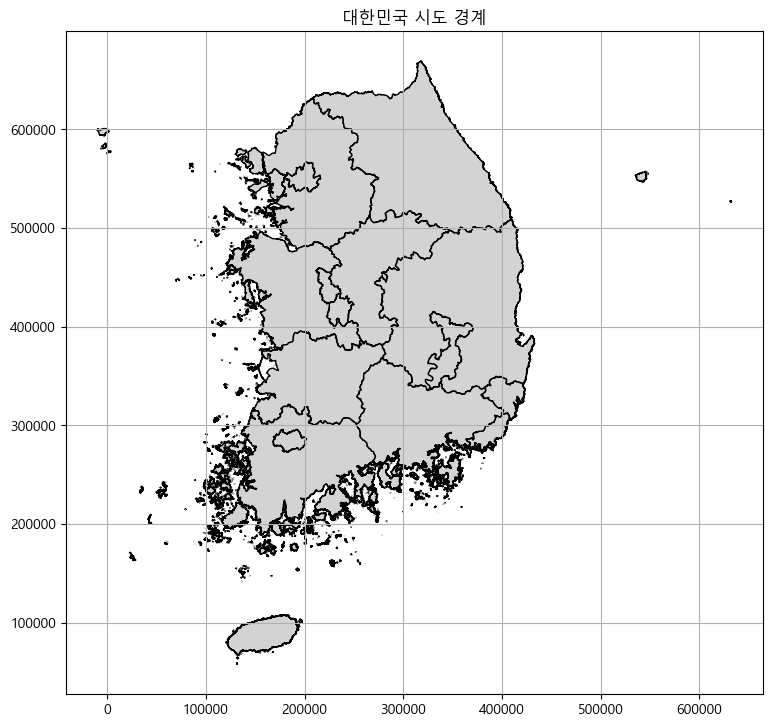

In [14]:
import matplotlib.pyplot as plt

# 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

ax = sido_gdf.plot(
  figsize=(9, 11),
  color="lightgray",
  edgecolor="black"
)

ax.set_title("대한민국 시도 경계")
ax.grid(True)

plt.show()

In [ ]:
# datas_df["총합"] = datas_df[["65-69세", "70-74세", "75-79세", "80-84세", "85세이상"]].sum(axis=1)
# datas_df

,65-69세,70-74세,75-79세,80-84세,85세이상,시도,연도,총합
0,88603,69505,57712,45157,30904,서울 Seoul,2022,291881
1,46276,37456,29862,23921,14433,부산 Busan,2022,151948
2,27586,22314,17546,15726,10597,대구 Daegu,2022,93769
3,28165,20192,16766,13504,9779,인천 Incheon,2022,88406
4,13603,11203,9508,8004,5428,광주 Gwangju,2022,47746
5,14870,11012,8847,7479,5384,대전 Daejeon,2022,47592
6,11156,8111,5909,4405,2703,울산 Ulsan,2022,32284
7,2140,1512,1207,1059,871,세종 Sejong,2022,6789
8,108953,78302,65344,53678,37515,경기 Gyeonggi,2022,343792
9,22311,16371,15769,14517,10519,강원 Gangwon,2022,79487


In [24]:
concat_df = pd.concat((
  sido_gdf, datas_df
), axis=1)

print(type(concat_df))
concat_df

<class 'geopandas.geodataframe.GeoDataFrame'>


,BASE_DATE,SIDO_CD,SIDO_NM,geometry,65-69세,70-74세,75-79세,80-84세,85세이상,시도,연도,총합
0,20250630,11,서울특별시,"POLYGON ((201748.532 566815.017, 201953.244 56...",88603,69505,57712,45157,30904,서울 Seoul,2022,291881
1,20250630,21,부산광역시,"MULTIPOLYGON (((378441.217 256011.416, 378440....",46276,37456,29862,23921,14433,부산 Busan,2022,151948
2,20250630,22,대구광역시,"POLYGON ((330688.544 415299.942, 330688.134 41...",27586,22314,17546,15726,10597,대구 Daegu,2022,93769
3,20250630,23,인천광역시,"MULTIPOLYGON (((91935.674 481967.049, 91936.11...",28165,20192,16766,13504,9779,인천 Incheon,2022,88406
4,20250630,24,광주광역시,"POLYGON ((178186.33 295822.605, 178255.423 295...",13603,11203,9508,8004,5428,광주 Gwangju,2022,47746
5,20250630,25,대전광역시,"POLYGON ((235744.989 432391.437, 235851.457 43...",14870,11012,8847,7479,5384,대전 Daejeon,2022,47592
6,20250630,26,울산광역시,"MULTIPOLYGON (((410247.66 306050.069, 410246.8...",11156,8111,5909,4405,2703,울산 Ulsan,2022,32284
7,20250630,29,세종특별자치시,"POLYGON ((214835.355 459451.226, 214843.683 45...",2140,1512,1207,1059,871,세종 Sejong,2022,6789
8,20250630,31,경기도,"MULTIPOLYGON (((185484.662 483430.4, 185529.37...",108953,78302,65344,53678,37515,경기 Gyeonggi,2022,343792
9,20250630,32,강원특별자치도,"MULTIPOLYGON (((410017.021 508090.999, 410009....",22311,16371,15769,14517,10519,강원 Gangwon,2022,79487


Text(0.5, 1.0, '독거노인 65세 이상 비율')

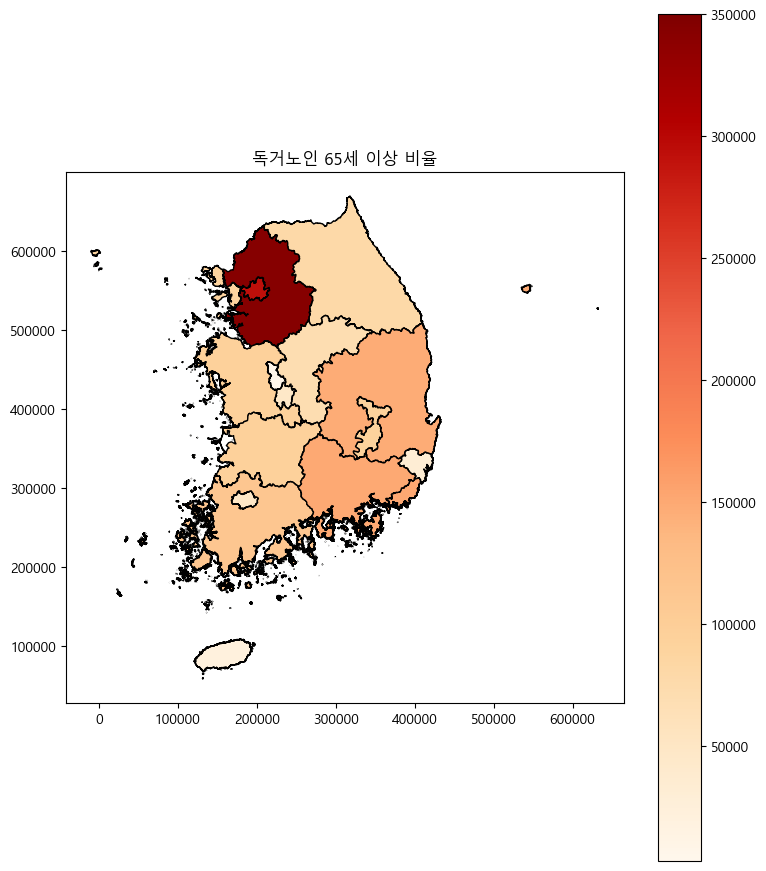

In [40]:
choice = {
  0: "총합", 
  1: "65-69세", 
  2: "70-74세", 
  3: "75-79세", 
  4: "80-84세", 
  5: "85세이상"
}.get(0)

ax = concat_df.plot(
  column=choice,
  figsize=(9, 11),
  legend=True,
  edgecolor="black",
  cmap="OrRd",
  vmin=3_000,
  vmax=350_000
)

ax.set_title(f"독거노인 65세 이상 비율")